**Notebook for Looking at the IOU of segmentation output for YOLOv8 model**

In [2]:
import ultralytics
from ultralytics import YOLO
import os
import numpy as np
import cv2
import time
import torch
import random
import shutil
import tqdm

In [3]:
print("CUDA Available: " + str(torch.cuda.is_available()))
print("Torch CUDA Version: " + str(torch.version.cuda))
# Check to make sure CUDA is available and does not say "None"
ultralytics.utils.checks.collect_system_info()

Ultralytics YOLOv8.1.27 🚀 Python-3.11.8 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 4090 Laptop GPU, 16054MiB)
Setup complete ✅ (32 CPUs, 31.0 GB RAM, 967.0/3666.0 GB disk)



OS                  Linux-6.8.0-52-generic-x86_64-with-glibc2.35
Environment         Jupyter
Python              3.11.8
Install             pip
RAM                 31.02 GB
CPU                 AMD Ryzen 9 7945HX with Radeon Graphics
CUDA                12.1

matplotlib          ✅ 3.8.3>=3.3.0
opencv-python       ✅ 4.9.0.80>=4.6.0
pillow              ✅ 10.2.0>=7.1.2
pyyaml              ✅ 6.0.1>=5.3.1
requests            ✅ 2.31.0>=2.23.0
scipy               ✅ 1.12.0>=1.4.1
torch               ✅ 2.2.1>=1.8.0
torchvision         ✅ 0.17.1>=0.9.0
tqdm                ✅ 4.66.2>=4.64.0
psutil              ✅ 5.9.8
py-cpuinfo          ✅ 9.0.0
thop                ✅ 0.1.1-2209072238>=0.1.1
pandas              ✅ 2.2.1>=1.1.4
seaborn             ✅ 0.13.2>=0.11.0


In [4]:
CURR_DIR = os.getcwd()
WORKSPACE_DIR = os.path.dirname(CURR_DIR)
DATASETS_DIR = WORKSPACE_DIR + '/../data'
DATA_YAML = WORKSPACE_DIR + '/data.yaml'
# CURR_RUN = 'ims_2024_day4_run1_vimba_front_frameskip_5_filtered'
# TEST_PATH = DATASETS_DIR + f'/{CURR_RUN}/images/'
TEST_IMAGES = DATASETS_DIR + '/test/images/'
TEST_LABELS = DATASETS_DIR + '/test/labels/'
x = 10
with os.scandir(TEST_IMAGES) as entries:
    for entry in entries:
        print(entry.name)
        x-=1
        if x < 0:
            break

ks_2024_day11_run3_vimba_front_Image_0000008102_1723321064_263345668_106404_0.jpg
ks_2024_day11_run3_vimba_front_Image_0000034524_1723322385_385078253_109093_0.jpg
ks_2024_inverted_vimba_rear_08_21-16_08_19_job-776_frame_000250_106585_0.jpg
ks_2024_inverted_vimba_rear_08_21-16_08_19_job-776_frame_002605_110071_0.jpg
ims_2024_day6_run1_vimba_front_filtered_frame_000131_111494_0.jpg
ks_2024_day11_run3_vimba_right_Image_0000012035_1723321261_9959846_107517_0.jpg
ks_2024_inverted_vimba_rear_08_21-16_08_19_job-776_frame_000607_106361_0.jpg
ks_2024_day11_run3_vimba_front_Image_0000004013_1723320859_809683606_109781_0.jpg
ks_2024_vimba_rear_08_13-12_42_57_job-15_frame_000369_107063_0.jpg
ks_2024_day11_run3_vimba_front_Image_0000024960_1723321907_178030236_107818_0.jpg
ks_2024_inverted_vimba_rear_08_21-16_08_19_job-776_frame_001223_107387_0.jpg


In [5]:
def polygon_to_mask(label_path: os.PathLike, img_width: int, img_height: int) -> np.ndarray:
    with open(label_path, 'r') as f:
        # if there are any lines in the file, each represents a detection segmentation
        lines = f.readlines()
        mask = np.zeros((img_height, img_width), dtype=np.uint8)
        for line in lines:
            entries = line.split(' ')[1:]
            points = [float(entry) for entry in entries]

            # get rid of the first one because it's the detection class
            # the points are alternating x y x y, so we can just take the even and odd indices
            x_points = np.array([points[i]*img_width for i in range(0, len(points), 2)])
            y_points = np.array([points[i]*img_height for i in range(1, len(points), 2)])
            seg_vertices = np.column_stack((x_points, y_points)).astype(np.int32)
            cv2.fillPoly(mask, [seg_vertices], 1)
    return mask

def overlay_masks(img, masks, color=(0, 255, 0), alpha=0.5):
    overlay = img.copy()
    for mask in masks:
        overlay[mask == 1] = color
    return cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)


# Just me testing this

TEST_SINGLE_LABEL = TEST_LABELS + 'coco_ks_2024_day17_run1_vimba_left_frameskip_5_frame_000077_106168_0.txt'
TEST_SINGLE_IMAGE = TEST_IMAGES + 'coco_ks_2024_day17_run1_vimba_left_frameskip_5_frame_000077_106168_0.jpg'



img = cv2.imread(TEST_SINGLE_IMAGE)
mask = polygon_to_mask(TEST_SINGLE_LABEL, img.shape[1], img.shape[0])
img = overlay_masks(img, [mask])
# save_path = os.path.join(WORKSPACE_DIR, 'coco_ks_2024_day17_run1_vimba_left_frameskip_5_frame_000077_106168_0.jpg')
# cv2.imwrite(save_path, img)
cv2.imshow('image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [6]:
def get_pred_mask(model: YOLO, img_path: os.PathLike, img_shape: tuple) -> np.ndarray:
    img = cv2.imread(img_path)
    results = model.predict(img_path)
    combined_mask = np.zeros((img_shape[0], img_shape[1]), dtype=np.uint8)
    for result in results:
        if result.masks is not None:
            mask_arr = result.masks.data.cpu().numpy()

            for i in range(mask_arr.shape[0]):
                bbox = result.boxes.xyxy[i]
                width = abs(bbox[2] - bbox[0])
                height = abs(bbox[3] - bbox[1])
                bbox_area = width * height
                confidence = result.boxes.conf[i]
                if bbox_area > 30 or confidence > 0.1:
                    binary_mask = (mask_arr[i] > 0.5).astype(np.uint8)
                    resized_mask = cv2.resize(binary_mask, (img_shape[1], img_shape[0]))
                    combined_mask = np.maximum(combined_mask, resized_mask)
    return combined_mask




def test_mask_iou(model: YOLO, test_images: os.PathLike, test_labels: os.PathLike):
    iou_array = []
    fn = 0
    fp = 0
    tn = 0
    tp = 0
    x = 0
    bad_segs = 0
    for file in os.listdir(test_images):
            x+=1
            img_path = os.path.join(test_images, file)
            label_path = os.path.join(test_labels, file.replace('.jpg', '.txt'))
            img = cv2.imread(img_path)
            true_mask = polygon_to_mask(label_path, img.shape[1], img.shape[0])
            pred_mask = get_pred_mask(model, img_path, img.shape)
            intersection = np.logical_and(true_mask, pred_mask)
            union = np.logical_or(true_mask, pred_mask)
            iou = np.sum(intersection) / np.sum(union) if np.sum(union) > 0 else 0
            if iou > 0:
                iou_array.append(iou)
            if iou > 0:
                tp+=1
            elif np.sum(true_mask) == 0 and np.sum(pred_mask) == 0:
                tn+=1
            elif np.sum(true_mask) == 0 and np.sum(pred_mask) > 0:
                fp+=1
            elif np.sum(true_mask) > 0 and np.sum(pred_mask) == 0:
                fn+=1
            else:
                # if it gets here, then IOU is 0 but there are still 2 masks
                bad_segs+=1

            ## For Displaying images that have a detection, just make sure to hit a button to close window instead of clicking on the x
            # if x > 500 and (np.sum(true_mask) > 0 or np.sum(pred_mask) > 0):
            #     pred_img = overlay_masks(img.copy(), [pred_mask], color=(0, 255, 0), alpha=0.5)
            #     true_img = overlay_masks(img.copy(), [true_mask], color=(255, 0, 0), alpha=0.5)
            #     stacked_img = np.hstack((pred_img, true_img))
            #     cv2.imshow('image', stacked_img)
            #     cv2.waitKey(0)
            #     cv2.destroyAllWindows()
            #     x = 0
            
    print(f'TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}, Bad Segs: {bad_segs}')
    print(f'TP Rate: {tp/(tp+fn)}')
    print(f'FP Rate: {fp/(fp+tn)}')
    print(f'TN Rate: {tn/(tn+fp)}')
    print(f'FN Rate: {fn/(fn+tp)}')
    print(f'Bad Seg Rate: {bad_segs/(tp+fn+fp+tn+bad_segs)}')
    return iou_array
            
            



In [8]:
CURR_MODEL_PATH = CURR_DIR + '/runs/segment/yolov8n-img_size_640_layers_frozen_0_2025-02-11-09-11-39/weights/best.pt'
RELOADED_MODEL_PATH = CURR_DIR + '/runs/segment/yolov8n-img_size_640_layers_frozen_0_2025-02-10-23-10-09/weights/best.pt'
MODEL_1032_PATH = CURR_DIR + '/yolov8n-seg_1032_best.pt'
model = YOLO(RELOADED_MODEL_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
ious = test_mask_iou(model, TEST_IMAGES, TEST_LABELS)



image 1/1 /home/tpark/Desktop/YOLOv8-Fine-Tune/../data/test/images/ks_2024_day11_run3_vimba_front_Image_0000008102_1723321064_263345668_106404_0.jpg: 480x640 (no detections), 3.1ms
Speed: 0.9ms preprocess, 3.1ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/tpark/Desktop/YOLOv8-Fine-Tune/../data/test/images/ks_2024_day11_run3_vimba_front_Image_0000034524_1723322385_385078253_109093_0.jpg: 480x640 (no detections), 3.0ms
Speed: 0.9ms preprocess, 3.0ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/tpark/Desktop/YOLOv8-Fine-Tune/../data/test/images/ks_2024_inverted_vimba_rear_08_21-16_08_19_job-776_frame_000250_106585_0.jpg: 480x640 (no detections), 2.6ms
Speed: 0.7ms preprocess, 2.6ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/tpark/Desktop/YOLOv8-Fine-Tune/../data/test/images/ks_2024_inverted_vimba_rear_08_21-16_08_19_job-776_frame_002605_110071_0.jpg: 480x640 (no detections), 

(array([          3,           0,           3,           0,           7,           3,           3,           1,           0,           3,           4,          10,           8,           6,           7,          15,          10,          11,          24,          22,          29,          28,          26,          34,
                 32,          29,          27,          23,          37,          32,          39,          73,          44,          55,          42,          35,          38,          50,          34,          27,          38,          29,          36,          46,          34,          49,          67,          64,
                 41,          20]),
 array([   0.013361,    0.032141,    0.050922,    0.069702,    0.088482,     0.10726,     0.12604,     0.14482,      0.1636,     0.18238,     0.20116,     0.21995,     0.23873,     0.25751,     0.27629,     0.29507,     0.31385,     0.33263,     0.35141,     0.37019,     0.38897,     0.40775,     0.42653,     0.44531,
    

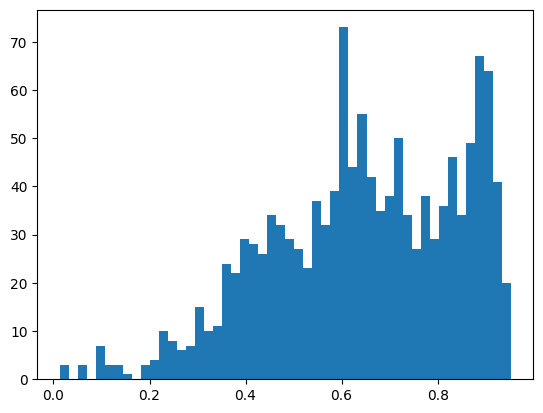

In [9]:
import matplotlib.pyplot as plt
import numpy

# img is lots of ious

plt.hist(ious, bins=50)

In [10]:
print("For img_sz 640:                TP: 1301, TN: 8252, FP: 63, FN: 130, Bad Segs: 9")
print("For img_sz 640 only 50 epochs: TP: 1298, TN: 8227, FP: 88, FN: 132, Bad Segs: 10")

For img_sz 640:                TP: 1301, TN: 8252, FP: 63, FN: 130, Bad Segs: 9
For img_sz 640 only 50 epochs: TP: 1298, TN: 8227, FP: 88, FN: 132, Bad Segs: 10


In [18]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ultralytics import YOLO

def polygon_to_mask(label_path: os.PathLike, img_width: int, img_height: int) -> np.ndarray:
    """Convert YOLO segmentation annotations into a binary mask."""
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    if not os.path.exists(label_path):
        return mask  # If there's no label file, just return an empty mask

    with open(label_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            # Skip the class ID and take the rest as polygon coordinates
            entries = line.split(' ')[1:]
            points = [float(entry) for entry in entries]

            x_points = np.array([points[i] * img_width for i in range(0, len(points), 2)])
            y_points = np.array([points[i] * img_height for i in range(1, len(points), 2)])
            seg_vertices = np.column_stack((x_points, y_points)).astype(np.int32)
            cv2.fillPoly(mask, [seg_vertices], 1)

    return mask

def get_pred_mask(results_obj, img_shape: tuple, conf_thresh: float, box_size_thresh: float) -> np.ndarray:
    """Generate a predicted segmentation mask from the YOLO model results.
    
    Only include detections if they have a confidence above 'conf_thresh'
    AND if their bounding box area is larger than 'box_size_thresh'.
    """
    combined_mask = np.zeros((img_shape[0], img_shape[1]), dtype=np.uint8)

    if results_obj.masks is not None:
        mask_arr = results_obj.masks.data.cpu().numpy()
        for i in range(mask_arr.shape[0]):
            bbox = results_obj.boxes.xyxy[i].cpu().numpy()
            confidence = results_obj.boxes.conf[i].cpu().numpy()

            width = abs(bbox[2] - bbox[0])
            height = abs(bbox[3] - bbox[1])
            bbox_area = width * height

            # Only add the mask if both conditions are met:
            if confidence > conf_thresh and bbox_area > box_size_thresh:
                binary_mask = (mask_arr[i] > 0.5).astype(np.uint8)
                resized_mask = cv2.resize(binary_mask, (img_shape[1], img_shape[0]))
                combined_mask = np.maximum(combined_mask, resized_mask)

    return combined_mask

def evaluate_yolo_masks(model, test_images, test_labels, iou_threshold=0.5):
    """Evaluate the YOLO segmentation model over different threshold settings.
    
    For each test image, we generate the ground truth mask from polygon annotations,
    run the prediction only once, and then evaluate how well the prediction works
    across a range of confidence and bounding box size thresholds.
    """
    confidence_thresholds = np.linspace(0.1, 0.9, 10)  # Different confidence levels to try
    box_size_thresholds = np.linspace(20, 500, 10)  # Different bounding box area thresholds

    results_dict = {conf: {box: {"TP": 0, "FP": 0, "FN": 0, "TN": 0, "Bad": 0} 
                           for box in box_size_thresholds} 
                    for conf in confidence_thresholds}

    for file in os.listdir(test_images):
        img_path = os.path.join(test_images, file)
        label_path = os.path.join(test_labels, file.replace('.jpg', '.txt'))

        img = cv2.imread(img_path)
        if img is None:
            continue

        # Build the ground truth mask using the provided polygon annotations.
        true_mask = polygon_to_mask(label_path, img.shape[1], img.shape[0])

        # Run the YOLO prediction once for this image.
        results_obj = model.predict(img_path)[0]

        for conf_thresh in confidence_thresholds:
            for box_size_thresh in box_size_thresholds:
                # Generate the predicted mask based on both the confidence and box size thresholds.
                pred_mask = get_pred_mask(results_obj, img.shape, conf_thresh, box_size_thresh)

                # Compute the Intersection over Union (IoU) between the true and predicted masks.
                intersection = np.logical_and(true_mask, pred_mask)
                union = np.logical_or(true_mask, pred_mask)
                iou = np.sum(intersection) / np.sum(union) if np.sum(union) > 0 else 0

                # Record the outcome based on IoU and whether the mask was predicted.
                if iou > iou_threshold:
                    results_dict[conf_thresh][box_size_thresh]["TP"] += 1
                elif np.sum(true_mask) == 0 and np.sum(pred_mask) == 0:
                    results_dict[conf_thresh][box_size_thresh]["TN"] += 1
                elif np.sum(true_mask) == 0 and np.sum(pred_mask) > 0:
                    results_dict[conf_thresh][box_size_thresh]["FP"] += 1
                elif np.sum(true_mask) > 0 and np.sum(pred_mask) == 0:
                    results_dict[conf_thresh][box_size_thresh]["FN"] += 1
                else:
                    results_dict[conf_thresh][box_size_thresh]["Bad"] += 1

    return results_dict

# Paths for the models (unchanged)
CURR_MODEL_PATH = CURR_DIR + '/runs/segment/yolov8n-img_size_640_layers_frozen_0_2025-02-11-09-11-39/weights/best.pt'
RELOADED_MODEL_PATH = CURR_DIR + '/runs/segment/yolov8n-img_size_640_layers_frozen_0_2025-02-10-23-10-09/weights/best.pt'
MODEL_1032_PATH = CURR_DIR + '/yolov8n-seg_1032_best.pt'

# Load the model from one of the given paths.
model = YOLO(CURR_MODEL_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Run evaluation on the test images and labels.
results_dict = evaluate_yolo_masks(model, TEST_IMAGES, TEST_LABELS)



image 1/1 /home/tpark/Desktop/YOLOv8-Fine-Tune/../data/test/images/ks_2024_day11_run3_vimba_front_Image_0000008102_1723321064_263345668_106404_0.jpg: 480x640 (no detections), 2.8ms
Speed: 0.9ms preprocess, 2.8ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/tpark/Desktop/YOLOv8-Fine-Tune/../data/test/images/ks_2024_day11_run3_vimba_front_Image_0000034524_1723322385_385078253_109093_0.jpg: 480x640 (no detections), 3.2ms
Speed: 1.0ms preprocess, 3.2ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/tpark/Desktop/YOLOv8-Fine-Tune/../data/test/images/ks_2024_inverted_vimba_rear_08_21-16_08_19_job-776_frame_000250_106585_0.jpg: 480x640 (no detections), 3.1ms
Speed: 1.2ms preprocess, 3.1ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/tpark/Desktop/YOLOv8-Fine-Tune/../data/test/images/ks_2024_inverted_vimba_rear_08_21-16_08_19_job-776_frame_002605_110071_0.jpg: 480x640 (no detections), 

Best metric combinations:
Highest Precision: 1.0000 at Confidence Threshold 0.900 and Box Size Threshold 20.000
Highest Recall:    0.8841 at Confidence Threshold 0.100 and Box Size Threshold 20.000
Highest F1 Score:  0.9113 at Confidence Threshold 0.100 and Box Size Threshold 20.000


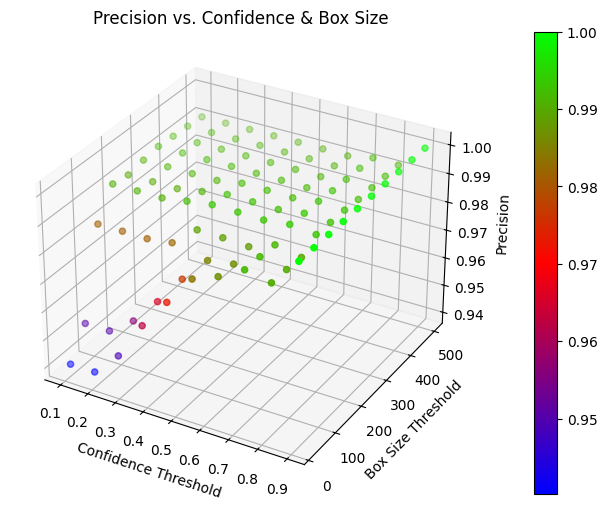

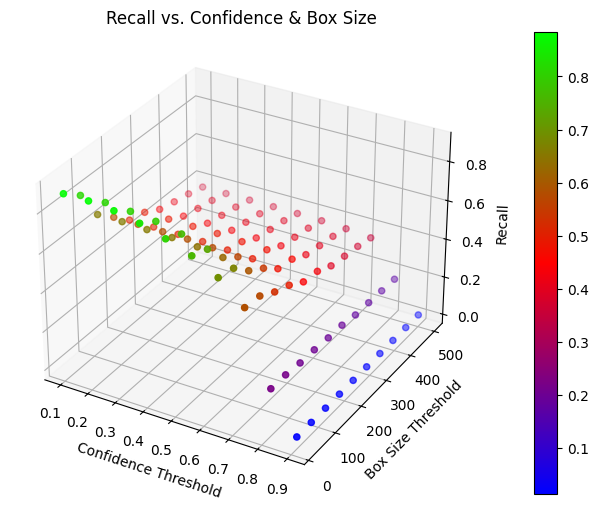

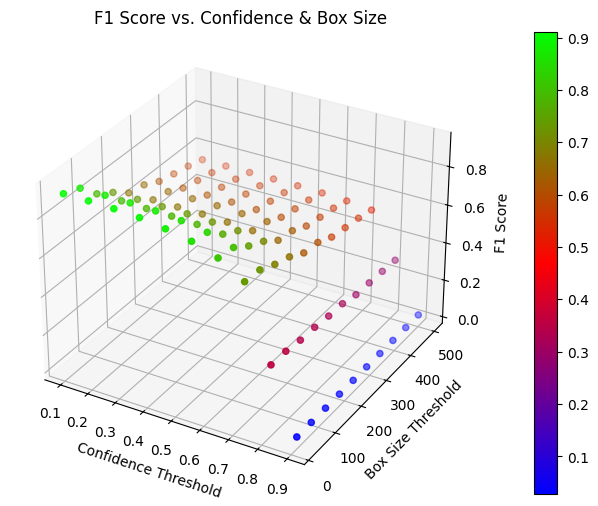

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def process_results(results_dict):
    """
    Let's convert our stored counts (TP, FP, FN, TN) into performance metrics.
    We calculate:
      - Precision: How many of the detected positives are actually correct.
      - Recall: How many of the actual positives we managed to detect.
      - F1-score: A balanced metric that combines precision and recall.
      
    For every combination of confidence and box size thresholds, we store these values.
    """
    processed_results = []

    for conf_thresh, box_dict in results_dict.items():
        for box_size_thresh, values in box_dict.items():
            tp, fp, fn, tn = values["TP"], values["FP"], values["FN"], values["TN"]

            # Calculate precision and recall, making sure we don't divide by zero.
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0

            # F1 score is the harmonic mean of precision and recall.
            f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            processed_results.append((conf_thresh, box_size_thresh, f1_score, precision, recall))

    return processed_results

def plot_precision(results):
    """Create a 3D scatter plot to show how precision changes with the thresholds."""
    conf_vals, box_size_vals, _, precision_vals, _ = zip(*results)
    conf_vals = np.array(conf_vals)
    box_size_vals = np.array(box_size_vals)
    precision_vals = np.array(precision_vals)
    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(conf_vals, box_size_vals, precision_vals, c=precision_vals, cmap='brg')
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Box Size Threshold')
    ax.set_zlabel('Precision')
    ax.set_title('Precision vs. Confidence & Box Size')
    fig.colorbar(sc, ax=ax, pad=0.1)
    plt.show()

def plot_recall(results):
    """Create a 3D scatter plot to show how recall varies with the thresholds."""
    conf_vals, box_size_vals, _, _, recall_vals = zip(*results)
    conf_vals = np.array(conf_vals)
    box_size_vals = np.array(box_size_vals)
    recall_vals = np.array(recall_vals)
    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(conf_vals, box_size_vals, recall_vals, c=recall_vals, cmap='brg')
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Box Size Threshold')
    ax.set_zlabel('Recall')
    ax.set_title('Recall vs. Confidence & Box Size')
    fig.colorbar(sc, ax=ax, pad=0.1)
    plt.show()

def plot_f1(results):
    """Create a 3D scatter plot to show how the F1 score changes with our thresholds."""
    conf_vals, box_size_vals, f1_scores, _, _ = zip(*results)
    conf_vals = np.array(conf_vals)
    box_size_vals = np.array(box_size_vals)
    f1_scores = np.array(f1_scores)
    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(conf_vals, box_size_vals, f1_scores, c=f1_scores, cmap='brg')
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Box Size Threshold')
    ax.set_zlabel('F1 Score')
    ax.set_title('F1 Score vs. Confidence & Box Size')
    fig.colorbar(sc, ax=ax, pad=0.1)
    plt.show()

# Process our results to calculate precision, recall, and F1 score.
processed_results = process_results(results_dict)

# Let's find the best threshold combination for each metric.
# Each tuple here is: (confidence threshold, box size threshold, F1-score, precision, recall)
best_precision = max(processed_results, key=lambda x: x[3])
best_recall    = max(processed_results, key=lambda x: x[4])
best_f1        = max(processed_results, key=lambda x: x[2])

print("Best metric combinations:")
print(f"Highest Precision: {best_precision[3]:.4f} at Confidence Threshold {best_precision[0]:.3f} and Box Size Threshold {best_precision[1]:.3f}")
print(f"Highest Recall:    {best_recall[4]:.4f} at Confidence Threshold {best_recall[0]:.3f} and Box Size Threshold {best_recall[1]:.3f}")
print(f"Highest F1 Score:  {best_f1[2]:.4f} at Confidence Threshold {best_f1[0]:.3f} and Box Size Threshold {best_f1[1]:.3f}")

# Plot each metric in separate graphs.
plot_precision(processed_results)
plot_recall(processed_results)
plot_f1(processed_results)
